# Mutual Fund Industry EDA Analysis (2022–2025)

## Objective
Analyze mutual fund NAV trends, AUM growth, SIP inflows, investor demographics, folio growth and sector allocation.

In [29]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


📈 Task 1: NAV Trend Analysis (Plotly)
Goal: Plot daily NAV for all 40 schemes (2022-2026) and highlight the phases using Plotly.

Database Source: fact_nav table columns: amfi_code, date, nav.

In [30]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/processed/bluestock_mf.db")

fact_nav = pd.read_sql("SELECT * FROM fact_nav", conn)
fact_aum = pd.read_sql("SELECT * FROM fact_aum", conn)
fact_transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)

In [31]:
import plotly.express as px

fact_nav['date'] = pd.to_datetime(fact_nav['date'])

fig = px.line(
    fact_nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend (2022-2026)'
)

# Bull Run 2023
fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    fillcolor='green',
    opacity=0.15,
    annotation_text='Bull Run 2023'
)

# Market Correction 2024
fig.add_vrect(
    x0='2024-01-01',
    x1='2024-06-30',
    fillcolor='red',
    opacity=0.15,
    annotation_text='Market Correction 2024'
)

fig.show()

In [32]:
fig.write_html(
    "exported_charts/chart_1_nav_trends.png"
)

In [33]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/processed/bluestock_mf.db")

fact_nav = pd.read_sql(
    "SELECT * FROM fact_nav",
    conn
)

fact_nav['date'] = pd.to_datetime(fact_nav['date'])

print(fact_nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


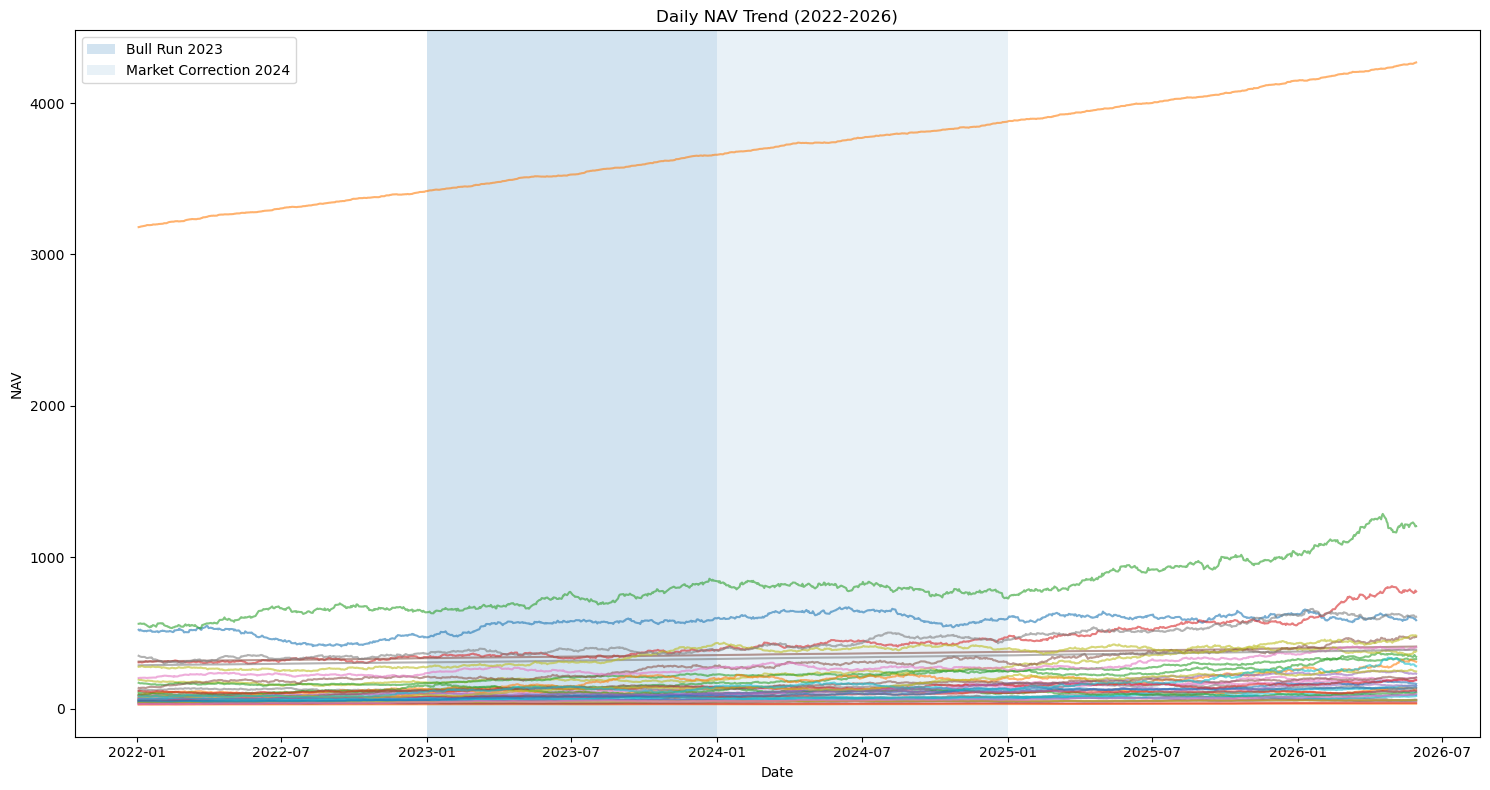

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

for code in fact_nav['amfi_code'].unique():
    
    temp = fact_nav[
        fact_nav['amfi_code'] == code
    ]
    
    plt.plot(
        temp['date'],
        temp['nav'],
        alpha=0.6
    )

# Highlight Bull Run 2023
plt.axvspan(
    pd.Timestamp('2023-01-01'),
    pd.Timestamp('2023-12-31'),
    alpha=0.2,
    label='Bull Run 2023'
)

# Highlight Correction 2024
plt.axvspan(
    pd.Timestamp('2024-01-01'),
    pd.Timestamp('2024-12-31'),
    alpha=0.1,
    label='Market Correction 2024'
)

plt.title('Daily NAV Trend (2022-2026)')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()

plt.tight_layout()

plt.savefig(
    'exported_charts/chart_1_nav_trends.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Finding 1 – NAV Trend Analysis
### Finding 1
Most mutual fund schemes experienced steady NAV growth during 2023, indicating a strong market bull run across equity-oriented funds.
**Chart Reference:** chart_1_nav_trends.png

📊 Task 2: AUM Growth Bar Chart (Seaborn)
Goal: Grouped bar chart by fund house for each year (2022–2025). Highlight SBI dominance.

Database Source: fact_aum table columns: date, fund_house, aum_crore.


In [35]:
!pip install pandas numpy matplotlib seaborn plotly kaleido

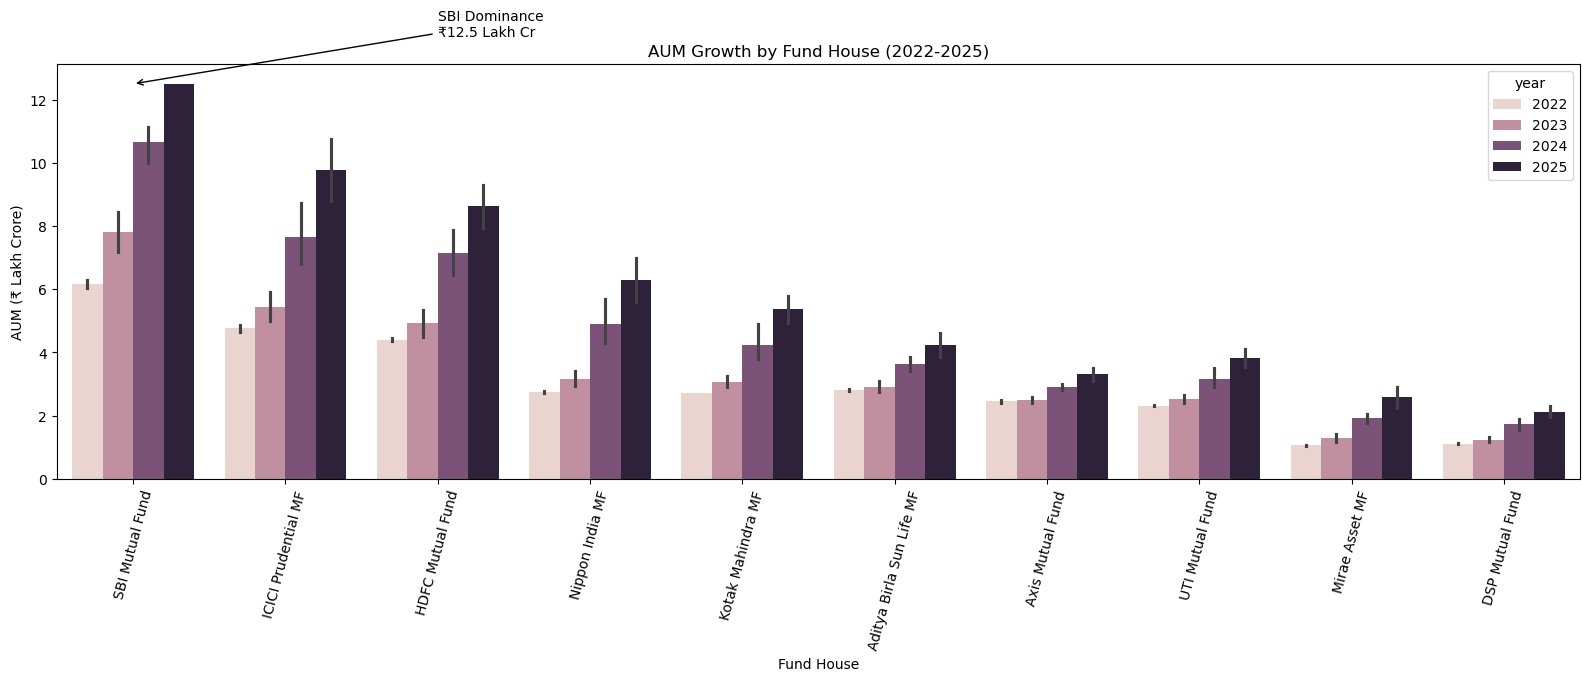

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fact_aum['date'] = pd.to_datetime(fact_aum['date'])
fact_aum['year'] = fact_aum['date'].dt.year

plt.figure(figsize=(16,7))

sns.barplot(
    data=fact_aum,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year'
)

plt.xticks(rotation=75)
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.title("AUM Growth by Fund House (2022-2025)")

plt.annotate(
    'SBI Dominance\n₹12.5 Lakh Cr',
    xy=(0, 12.5),
    xytext=(2, 14),
    arrowprops=dict(arrowstyle='->')
)

plt.tight_layout()

plt.savefig(
    "exported_charts/chart_2_aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

print(os.path.exists("exported_charts/chart_2_aum_growth.png"))

Finding 2 – AUM Growth Analysis
### Finding 2
SBI Mutual Fund maintained the highest Assets Under Management (AUM) and reached approximately ₹12.5 lakh crore by 2025.
**Chart Reference:** chart_2_aum_growth.png


In [ ]:
print(fact_aum.head())
print(fact_aum.groupby('year').size())

3. SIP Inflow Time-Series


In [ ]:
import pandas as pd

sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip_df.head())
print(sip_df.columns.tolist())

In [37]:
import pandas as pd
import plotly.express as px

# Load data
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

# Convert month to datetime
sip_df['month'] = pd.to_datetime(sip_df['month'])

# Create line chart
fig = px.line(
    sip_df,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)'
)

# Get Dec 2025 value
dec_2025 = sip_df[sip_df['month'] == '2025-12-01']

# Annotate all-time high
fig.add_annotation(
    x=dec_2025['month'].iloc[0],
    y=dec_2025['sip_inflow_crore'].iloc[0],
    text='₹31,002 Cr All-Time High (Dec 2025)',
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)',
    template='plotly_white'
)

fig.show()

In [ ]:
fig.write_html(
    "exported_charts/chart_3_sip_inflow.html"
)

In [ ]:

sip_df.tail()

#Finding 3 – SIP Inflow Trend
### Finding 3
Monthly SIP inflows showed a strong upward trend and reached an all-time high of ₹31,002 crore in December 2025.
**Chart Reference:** chart_3_sip_inflow.png


Task 4: Category Inflow Heatmap
Goal

Months on X-axis

Categories on Y-axis

Color = Net inflow amount

In [ ]:
import pandas as pd

category_df = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category_df.columns.tolist())
print(category_df.head())

In [ ]:
pivot_data = category_df.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

print(pivot_data.head())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,8))

sns.heatmap(
    pivot_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title(
    'Category-wise Monthly Net Inflow Heatmap',
    fontsize=14
)

plt.xlabel('Month')
plt.ylabel('Fund Category')

plt.tight_layout()

plt.savefig(
    'exported_charts/chart_4_category_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Finding 4
Flexi Cap, Large & Mid Cap, and Mid Cap categories consistently attracted higher net inflows than most other fund categories.
**Chart Reference:** chart_4_category_heatmap.png

5. Investor demographics — age group distribution pie chart. SIP amount box plot by age group. Gender split.

In [ ]:
import matplotlib.pyplot as plt

age_dist = fact_transactions['age_group'].value_counts()

print(age_dist)

In [ ]:
plt.figure(figsize=(7,5))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct='%1.1f%%'
)

plt.title('Investor Age Group Distribution')

plt.savefig(
    'exported_charts/chart_5_age_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Finding 5 – Investor Age Distribution
The 26–35 and 36–45 age groups represent the largest share of mutual fund investors.
(Refer: chart_5_age_distribution.png)

6.SIP amount box plot by age group

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sip = fact_transactions[
    fact_transactions['transaction_type'] == 'SIP'
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip,
    x='age_group',
    y='amount_inr'
)

plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (₹)')

plt.savefig(
    'exported_charts/chart_6_sip_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
#SIP Amount Box Plot by Age Group

Finding 6 – SIP Amount by Age Group
### Finding 6
Middle-aged investors generally contributed higher SIP amounts compared to younger investors.
**Chart Reference:** chart_6_sip_boxplot.png

In [ ]:
gender_dist = fact_transactions['gender'].value_counts()

print(gender_dist)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))

plt.pie(
    gender_dist,
    labels=gender_dist.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Gender Distribution of Investors')

plt.savefig(
    'exported_charts/chart_7_gender_split.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Finding 7 – Gender Distribution
Male investors constitute a larger share of the investor base compared to female investors.
(Refer: chart_7_gender_split.png)

Task 6: Geographic Distribution

In [ ]:
sip = fact_transactions[
    fact_transactions['transaction_type'] == 'SIP'
]

state_sip = sip.groupby(
    'state'
)['amount_inr'].sum().sort_values()
print(state_sip)

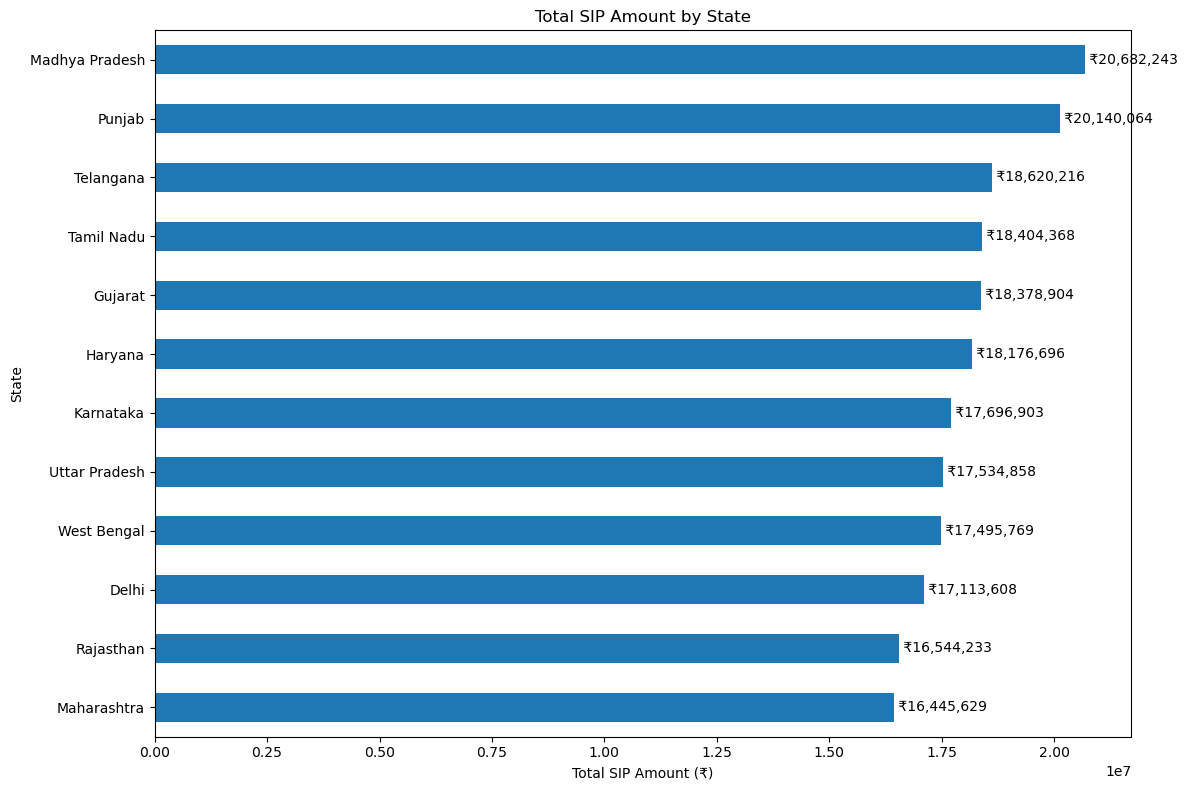

In [38]:
import matplotlib.pyplot as plt

# Filter SIP transactions
sip = fact_transactions[
    fact_transactions['transaction_type'] == 'SIP'
]

# Aggregate SIP amount by state
state_sip = sip.groupby(
    'state'
)['amount_inr'].sum().sort_values()

# Plot
plt.figure(figsize=(12,8))

ax = state_sip.plot(
    kind='barh'
)

plt.title('Total SIP Amount by State')
plt.xlabel('Total SIP Amount (₹)')
plt.ylabel('State')

# Add data labels
for i, value in enumerate(state_sip):
    ax.text(
        value,           # x-position
        i,               # y-position
        f' ₹{value:,.0f}',
        va='center'
    )

plt.tight_layout()

# Save chart
plt.savefig(
    'exported_charts/chart_8_state_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Finding 8
States containing major metropolitan cities generated the highest SIP investment volumes.
**Chart Reference:** chart_8_state_distribution.png

In [ ]:
tier_dist = fact_transactions['city_tier'].value_counts()
print(tier_dist)

In [ ]:
plt.figure(figsize=(4,4))

plt.pie(
    tier_dist,
    labels=tier_dist.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('T30 vs B30 City Tier Distribution')

plt.savefig(
    'exported_charts/chart_9_t30_b30.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Finding 9 – T30 vs B30 Cities
### Finding 9
T30 cities contributed a significantly larger share of mutual fund investments than B30 cities.
**Chart Reference:** chart_9_t30_b30.png

#8 . Folio count growth — line chart from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025). Mark key milestones.

In [ ]:
import pandas as pd

folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio_df.columns.tolist())
print(folio_df.head())
print(folio_df.tail())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

folio_df['month'] = pd.to_datetime(folio_df['month'])

print(folio_df[['month', 'total_folios_crore']].head())

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    folio_df['month'],
    folio_df['total_folios_crore'],
    marker='o',
    linewidth=2
)

plt.title('Industry Folio Count Growth (2022–2025)')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')

# Start milestone
plt.annotate(
    '13.26 Cr\n(Jan 2022)',
    xy=(folio_df['month'].iloc[0],
        folio_df['total_folios_crore'].iloc[0]),
    xytext=(folio_df['month'].iloc[1], 14),
    arrowprops=dict(arrowstyle='->')
)

# Mid milestone
mid = folio_df[
    folio_df['month'] == '2024-01-01'
]

if len(mid) > 0:
    plt.annotate(
        f"{mid['total_folios_crore'].iloc[0]:.2f} Cr\n(Jan 2024)",
        xy=(mid['month'].iloc[0],
            mid['total_folios_crore'].iloc[0]),
        xytext=(mid['month'].iloc[0], 20),
        arrowprops=dict(arrowstyle='->')
    )

# End milestone
plt.annotate(
    '26.12 Cr\n(Dec 2025)',
    xy=(folio_df['month'].iloc[-1],
        folio_df['total_folios_crore'].iloc[-1]),
    xytext=(folio_df['month'].iloc[-5], 24),
    arrowprops=dict(arrowstyle='->')
)

# Add data labels
for x, y in zip(
    folio_df['month'],
    folio_df['total_folios_crore']
):
    plt.text(
        x,
        y + 0.15,
        f'{y:.2f}',
        fontsize=8,
        ha='center'
    )

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'exported_charts/chart_10_folio_growth.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Finding 10 – Folio GrowthFindings
Industry folio counts increased from 13.26 crore in January 2022 to 26.12 crore in December 2025, nearly doubling over the period and indicating strong retail investor participation.
(Refer: chart_10_folio_growth.png)

Task 7 : NAV return correlation matrix — compute pairwise correlation of daily returns for 10 selected funds. Seaborn heatmap.


In [ ]:
# selectting 10 funds
top10 = fact_nav['amfi_code'].unique()[:10]

print(top10)

In [ ]:
#Step 2: Filter NAV Data
corr_df = fact_nav[
    fact_nav['amfi_code'].isin(top10)
].copy()
print(corr_df)

In [ ]:
# Convert Data
corr_df['date'] = pd.to_datetime(
    corr_df['date']
)
print(corr_df)

In [ ]:
#Step 4: Create Pivot Table
#Rows = Date
#Columns = Fund
#Values = NAV


pivot_nav = corr_df.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

print(pivot_nav.head())

In [ ]:
#Step 5: Calculate Daily Returns
returns = pivot_nav.pct_change()

print(returns.head())

In [ ]:
#Step 6: Correlation Matrix
corr_matrix = returns.corr()

print(corr_matrix)

In [ ]:
#Step 7: Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'NAV Return Correlation Matrix (10 Selected Funds)'
)

plt.tight_layout()

plt.savefig(
    'exported_charts/chart_12_nav_correlation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Findings
Most selected mutual funds show positive return correlations, indicating that they are influenced by common market movements.
(Refer: chart_12_nav_correlation.png)

Task 8. Sector allocation donut — aggregate sector weights from portfolio_holdings.csv across all equity funds.

In [ ]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(portfolio.columns.tolist())
print(portfolio.head())

In [ ]:
#Step 1: Aggregate Sector Weights
sector_alloc = portfolio.groupby(
    'sector'
)['weight_pct'].sum().sort_values(
    ascending=False
)

print(sector_alloc.head())

In [ ]:
#Step 2: Keep Top 10 Sectors (Recommended)
#This makes the chart cleaner.
top_sectors = sector_alloc.head(10)

print(top_sectors)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.pie(
    top_sectors,
    labels=top_sectors.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)

# Create donut hole
centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    'Sector Allocation Across Equity Funds'
)

plt.tight_layout()

plt.savefig(
    'exported_charts/chart_13_sector_allocation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Findings
Banking, Technology, Pharma and Financial Services sectors account for a significant share of portfolio allocations across equity mutual funds.
(Refer: chart_13_sector_allocation.png)

Missing Chart 11: Folio Growth by Category

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    folio_df['month'],
    folio_df['equity_folios_crore'],
    marker='o',
    label='Equity'
)

plt.plot(
    folio_df['month'],
    folio_df['debt_folios_crore'],
    marker='o',
    label='Debt'
)

plt.plot(
    folio_df['month'],
    folio_df['hybrid_folios_crore'],
    marker='o',
    label='Hybrid'
)

plt.legend()

plt.title('Folio Growth by Category')
plt.xlabel('Month')
plt.ylabel('Folios (Crore)')

plt.savefig(
    'exported_charts/chart_11_folio_category_growth.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Chart 14: Transaction Type Distribution

In [ ]:
plt.figure(figsize=(8,5))

fact_transactions['transaction_type'].value_counts().plot(kind='bar')

plt.title('Transaction Type Distribution')

plt.savefig(
    'exported_charts/chart_14_transaction_type.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Chart 15: Payment Mode Distribution

In [ ]:
plt.figure(figsize=(8,5))

fact_transactions['payment_mode'].value_counts().plot(kind='bar')

plt.title('Payment Mode Distribution')

plt.savefig(
    'exported_charts/chart_15_payment_mode.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Chart 16: KYC Status Distribution

In [ ]:
plt.figure(figsize=(7,7))

fact_transactions['kyc_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('KYC Status Distribution')

plt.savefig(
    'exported_charts/chart_16_kyc_status.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
fig.write_image(
    "exported_charts/chart_1_nav_trends.png"
)

In [ ]:
fig.write_image(
    "exported_charts/chart_3_sip_inflow.png"
)

In [ ]:
print(type(fig))

In [ ]:
import pandas as pd
import plotly.express as px

# Load file
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

# Convert month column
sip_df['month'] = pd.to_datetime(sip_df['month'])

# Create line chart
fig = px.line(
    sip_df,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)'
)

# Annotate all-time high
peak_row = sip_df.loc[
    sip_df['sip_inflow_crore'].idxmax()
]

fig.add_annotation(
    x=str(peak_row['month'].date()),  # Convert Timestamp to string
    y=float(peak_row['sip_inflow_crore']),
    text=f"₹{peak_row['sip_inflow_crore']:,} Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)',
    height=600,
    width=1000
)

fig.show()

# Save PNG
fig.write_image(
    "exported_charts/chart_3_sip_inflow.png",
    scale=3
)

In [ ]:
%pip install -U kaleido

In [ ]:
import pandas as pd
import plotly.express as px

sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip_df['month'] = pd.to_datetime(sip_df['month'])

fig = px.line(
    sip_df,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)'
)

peak_row = sip_df.loc[
    sip_df['sip_inflow_crore'].idxmax()
]

fig.add_annotation(
    x=str(peak_row['month'].date()),
    y=float(peak_row['sip_inflow_crore']),
    text=f"₹{peak_row['sip_inflow_crore']:,} Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2
)

fig.show()

fig.write_image(
    "exported_charts/chart_3_sip_inflow.png",
    scale=3
)

In [ ]:
%pip install -U plotly

In [ ]:
import plotly.express as px

fig = px.line(
    x=[1,2,3,4],
    y=[10,20,15,30],
    title="Test Chart"
)

fig.write_image("test_chart.png")
print("Saved successfully")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    sip_df['month'],
    sip_df['sip_inflow_crore'],
    marker='o',
    linewidth=2
)

peak = sip_df.loc[sip_df['sip_inflow_crore'].idxmax()]

plt.annotate(
    '₹31,002 Cr\n(Dec 2025)',
    xy=(peak['month'], peak['sip_inflow_crore']),
    xytext=(peak['month'], peak['sip_inflow_crore'] + 1500),
    arrowprops=dict(arrowstyle='->')
)

plt.title('Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (₹ Crore)')
plt.grid(True, alpha=0.3)

plt.savefig(
    'exported_charts/chart_3_sip_inflow.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()